# Testing resolution/frame-overlap when one of the double disc choppers are slowed down

# McStas Results from Mo

##  RRM=22

Ei | Mode | Resolution | Percetage
|---|---|---|---|
80 meV (1.011 Å)| OG | 3.67 meV | 4.6%
80 meV (1.011 Å)| M2 | 4.31 meV | 5.4%
50 meV (1.279 Å)| OG | 1.78 meV | 3.0%
50 meV (1.279 Å)| M2 | 2.07 meV | 4.1%
20 meV (2.022 Å)| OG | 0.46 meV | 2.3%
20 meV (2.022 Å)| M2 | 0.54 meV | 2.7%




# Original RRM=22, getting 17

In [1]:
%matplotlib widget

import numpy as np
import scipp as sc
from drtrex.instrument import Instrument
from drtrex.sample import Sample
from drtrex.components.source import Source


central_wavelength = 1.279 * sc.Unit("Å")
mode = "High Resolution"  # Chopper mode
rrm = 22
T_OFFSET = sc.scalar(1.7, unit="ms")

trex = Instrument(
    central_wavelength, rrm, mode, T_OFFSET, chopper_slowdown=(1, 1, 1, 1)
)
trex.source = Source(
    facility="ess-trex", neutrons=10_000_000, optimize_for=trex.choppers
)
res_elastic_rrm20_0 = trex.run()
sample = Sample(
    en={
        "choice": np.concatenate(
            [
                np.arange(-100, -80, 1e-2),
                np.arange(-20, -10, 1e-2),
                np.arange(-1, 1, 2e-3),
                np.arange(10, 20, 1e-2),
                np.arange(80, 100, 1e-2),
            ]
        )
    },
    name="inelastic",
)
res_inelastic_rrm20_0 = trex.run(sample)

# Inelastic

(160.0, 168.0)

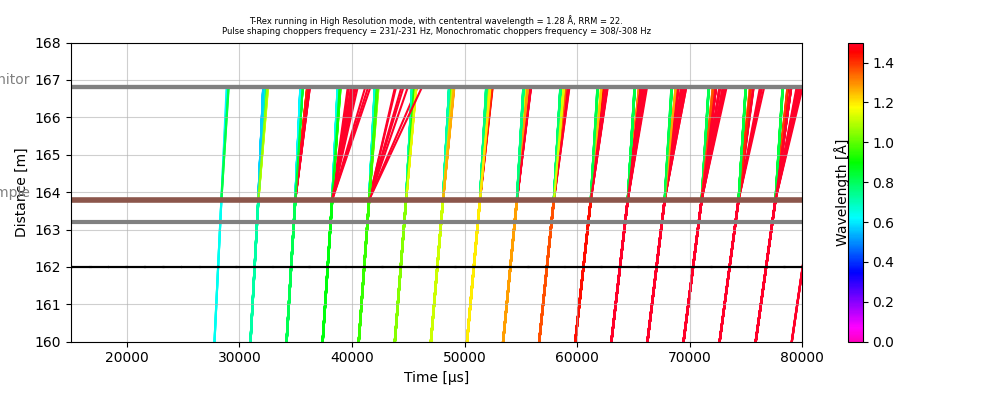

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

res_inelastic_rrm20_0.plot(ax=ax, vmin=0, vmax=1.5)
ax.set_title(str(trex), fontsize=6)
ax.grid(alpha=0.6)
fig.tight_layout()
ax.set_xlim([15_000, 80_000])
ax.set_ylim([160, 168])

In [3]:
import plopp as pp

data = res_inelastic_rrm20_0.detectors["Detector"].data["pulse", 0]
data = data[~data.masks["blocked_by_others"]]
pp.plot(data.hist(toa=sc.arange("toa", 15_000, 80_000, 1, unit="us")), grid=True)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [4]:
import plopp as pp

ei_ef_ratio = 0.0
trex.wrap_frame(res_elastic_rrm20_0)
params_0 = trex.unwrap_frame(res_elastic_rrm20_0, ei_ef_ratio=ei_ef_ratio)
# trex.wrap_frame(res_inelastic_rrm22)
reduced_ins_0 = trex.toa_to_energy(res_inelastic_rrm20_0, *params_0)
for reduced in reduced_ins_0:
    reduced.data *= reduced.coords["kf_over_ki"]
    reduced.data *= sc.sqrt(reduced.coords["ei"] / reduced.coords["ef"])

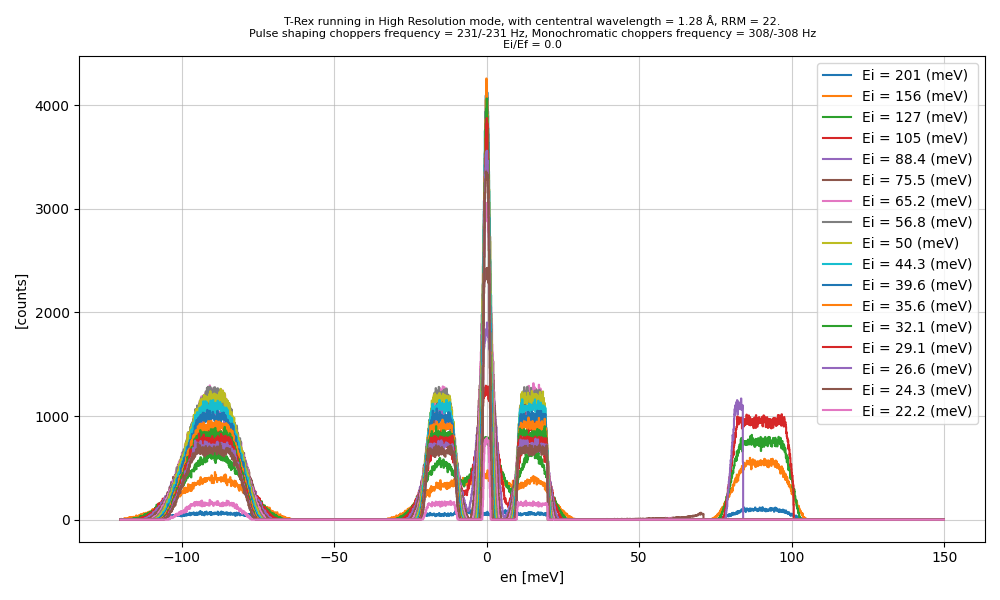

In [5]:
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", -120, 150, 0.1, unit="meV")
    )
    for reduced in reduced_ins_0
}

fig, ax = plt.subplots(figsize=(10, 6))
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex) + f"\nEi/Ef = {ei_ef_ratio}", fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

# Elastic

In [6]:
trex.wrap_frame(res_elastic_rrm20_0)
params_0 = trex.unwrap_frame(res_elastic_rrm20_0, ei_ef_ratio=0.0)
reduced_elastic_0 = trex.toa_to_energy(res_elastic_rrm20_0, *params_0)

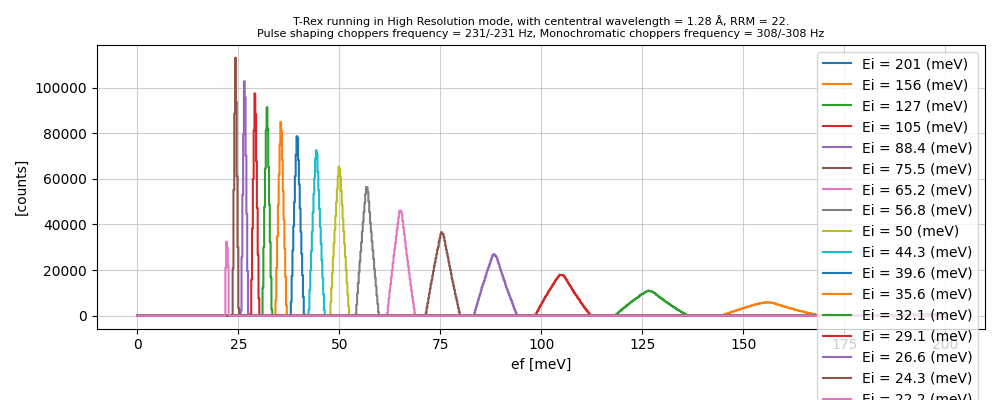

In [7]:
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        ef=sc.arange("ef", 0, 200, 0.2, unit="meV")
    )
    for reduced in reduced_elastic_0
}

fig, ax = plt.subplots(figsize=(10, 4))
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex), fontsize=8)
ax.grid(alpha=0.6)
# ax.set_ylim([-50, 12_000])
fig.tight_layout()

In [8]:
cen = [
    (da.data * sc.midpoints(da.coords["ef"])).sum() / da.sum()
    for da in hist_dict.values()
]
fwhm = [
    2.355
    * sc.sqrt(
        (da.data * (sc.midpoints(da.coords["ef"] - cen[i].data)) ** 2).sum() / da.sum()
    )
    for i, da in enumerate(hist_dict.values())
]
print(f"Ei  = {[round(float(v.data.value), 4) for v in cen]} meV")
print(f"delta en FWHM  = {[round(float(v.data.value), 4) for v in fwhm]} meV")
ratio = [round(float(f.data / c.data), 3) for f, c in zip(fwhm, cen)]
print(f"delta en over ei = {ratio}")

Ei  = [195.5818, 156.114, 126.8163, 105.0631, 88.4569, 75.4957, 65.186, 56.8532, 50.0238, 44.3543, 39.595, 35.564, 32.1176, 29.1487, 26.5734, 24.3247, 22.2018] meV
delta en FWHM  = [5.909, 11.7956, 8.7123, 6.6401, 5.1765, 4.128, 3.3416, 2.7434, 2.2832, 1.8931, 1.5845, 1.342, 1.141, 0.9809, 0.8498, 0.7402, 0.4892] meV
delta en over ei = [0.03, 0.076, 0.069, 0.063, 0.059, 0.055, 0.051, 0.048, 0.046, 0.043, 0.04, 0.038, 0.036, 0.034, 0.032, 0.03, 0.022]


# Reduce RRM to 20

In [9]:
rrm = 20
trex = Instrument(
    central_wavelength, rrm, mode, T_OFFSET, chopper_slowdown=(1, 1, 1, 1)
)
trex.source = Source(
    facility="ess-trex", neutrons=5_000_000, optimize_for=trex.choppers
)
res_elastic_rrm20_1 = trex.run()
# sample = Sample(en={"uniform": (40, 60)})
res_inelastic_rrm20_1 = trex.run(sample)

(160.0, 168.0)

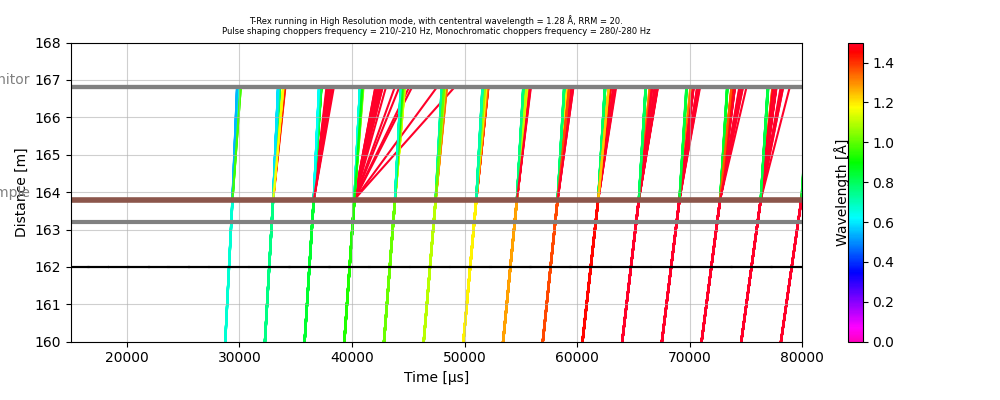

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

res_inelastic_rrm20_1.plot(ax=ax, vmin=0, vmax=1.5)
ax.set_title(str(trex), fontsize=6)
ax.grid(alpha=0.6)
fig.tight_layout()
ax.set_xlim([15_000, 80_000])
ax.set_ylim([160, 168])

In [11]:
import plopp as pp

data = res_inelastic_rrm20_1.detectors["Detector"].data["pulse", 0]
data = data[~data.masks["blocked_by_others"]]
pp.plot(data.hist(toa=sc.arange("toa", 15_000, 80_000, 1, unit="us")), grid=True)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [12]:
import plopp as pp

ei_ef_ratio = 0.0
trex.wrap_frame(res_elastic_rrm20_1)
params_1 = trex.unwrap_frame(res_elastic_rrm20_1, ei_ef_ratio=ei_ef_ratio)
# trex.wrap_frame(res_inelastic_rrm22)
reduced_ins_1 = trex.toa_to_energy(res_inelastic_rrm20_1, *params_1)
for reduced in reduced_ins_1:
    reduced.data *= reduced.coords["kf_over_ki"]
    reduced.data *= sc.sqrt(reduced.coords["ei"] / reduced.coords["ef"])

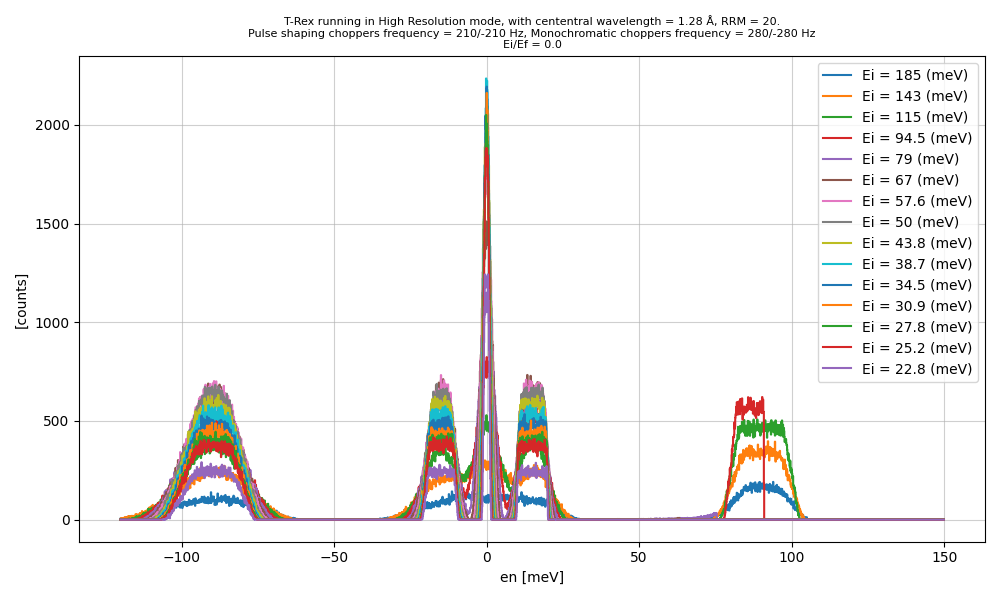

In [13]:
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", -120, 150, 0.1, unit="meV")
    )
    for reduced in reduced_ins_1
}

fig, ax = plt.subplots(figsize=(10, 6))
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex) + f"\nEi/Ef = {ei_ef_ratio}", fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

In [14]:
trex.wrap_frame(res_elastic_rrm20_1)
params_1 = trex.unwrap_frame(res_elastic_rrm20_1, ei_ef_ratio=0.0)
reduced_elastic_1 = trex.toa_to_energy(res_elastic_rrm20_1, *params_1)

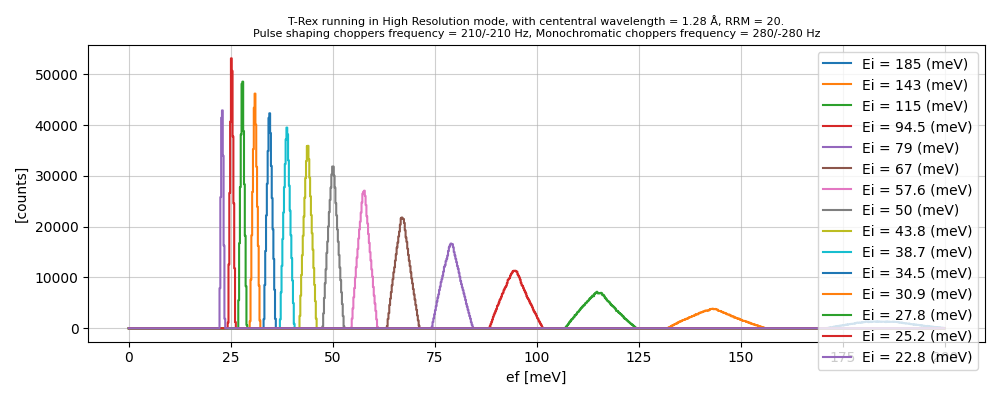

In [15]:
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        ef=sc.arange("ef", 0, 200, 0.2, unit="meV")
    )
    for reduced in reduced_elastic_1
}

fig, ax = plt.subplots(figsize=(10, 4))
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex), fontsize=8)
ax.grid(alpha=0.6)
# ax.set_ylim([-50, 12_000])
fig.tight_layout()

In [16]:
cen = [
    (da.data * sc.midpoints(da.coords["ef"])).sum() / da.sum()
    for da in hist_dict.values()
]
fwhm = [
    2.355
    * sc.sqrt(
        (da.data * (sc.midpoints(da.coords["ef"] - cen[i].data)) ** 2).sum() / da.sum()
    )
    for i, da in enumerate(hist_dict.values())
]
print(f"Ei  = {[round(float(v.data.value), 4) for v in cen]} meV")
print(f"delta en FWHM  = {[round(float(v.data.value), 4) for v in fwhm]} meV")
ratio = [round(float(f.data / c.data), 3) for f, c in zip(fwhm, cen)]
print(f"delta en over ei = {ratio}")

Ei  = [184.6886, 143.3166, 115.184, 94.6, 79.074, 67.0784, 57.6189, 50.0271, 43.8435, 38.7367, 34.4752, 30.8784, 27.8169, 25.1899, 22.8475] meV
delta en FWHM  = [14.4768, 11.5758, 8.3762, 6.3214, 4.8611, 3.8351, 3.0861, 2.5118, 2.0459, 1.6835, 1.4072, 1.1831, 1.0057, 0.8598, 0.6457] meV
delta en over ei = [0.078, 0.081, 0.073, 0.067, 0.061, 0.057, 0.054, 0.05, 0.047, 0.043, 0.041, 0.038, 0.036, 0.034, 0.028]


# Having M2 slowed down by a factor of 2

In [17]:
trex = Instrument(
    central_wavelength, rrm, mode, T_OFFSET, chopper_slowdown=(1, 1, 1, 2)
)
trex.source = Source(
    facility="ess-trex", neutrons=5_000_000, optimize_for=trex.choppers
)
res_elastic_rrm20_2 = trex.run()
# sample = Sample(en={"uniform": (40, 60)})
res_inelastic_rrm20_2 = trex.run(sample)

/var/folders/s5/6527bxpx7xnbbzxz94s_d2xm0000gp/T/ipykernel_53495/2617236884.py:10: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


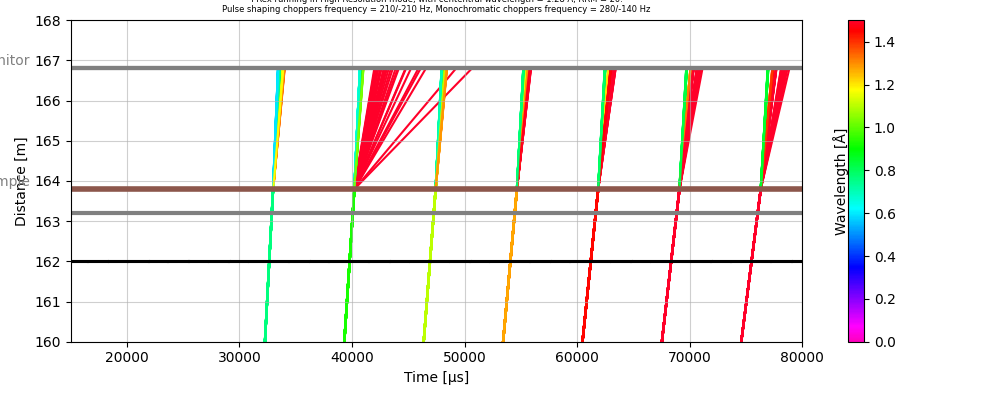

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

res_inelastic_rrm20_2.plot(ax=ax, vmin=0, vmax=1.5)
ax.set_xlim([15_000, 80_000])
ax.set_ylim([160, 168])
ax.set_title(str(trex), fontsize=6)
ax.grid(alpha=0.6)
fig.tight_layout()

In [19]:
data = res_inelastic_rrm20_2.detectors["Detector"].data["pulse", 0]
data = data[~data.masks["blocked_by_others"]]
pp.plot(data.hist(toa=sc.arange("toa", 15_000, 80_000, 1, unit="us")), grid=True)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [20]:
ei_ef_ratio = 0.0
trex.wrap_frame(res_elastic_rrm20_2)
params_2 = trex.unwrap_frame(res_elastic_rrm20_2, ei_ef_ratio=ei_ef_ratio)
# trex.wrap_frame(res_inelastic_rrm22)
reduced_ins_2 = trex.toa_to_energy(res_inelastic_rrm20_2, *params_2)
for reduced in reduced_ins_2:
    reduced.data *= reduced.coords["kf_over_ki"]
    reduced.data *= sc.sqrt(reduced.coords["ei"] / reduced.coords["ef"])

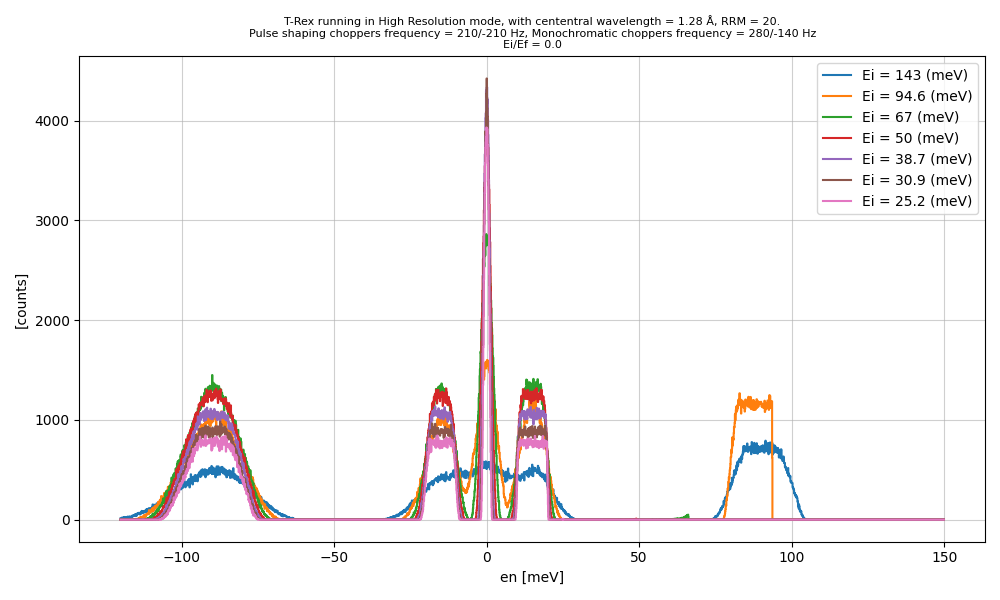

In [21]:
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", -120, 150, 0.1, unit="meV")
    )
    for reduced in reduced_ins_2
}

fig, ax = plt.subplots(figsize=(10, 6))
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex) + f"\nEi/Ef = {ei_ef_ratio}", fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

In [22]:
trex.wrap_frame(res_elastic_rrm20_2)
params_2 = trex.unwrap_frame(res_elastic_rrm20_2, ei_ef_ratio=0.0)
reduced_elastic_2 = trex.toa_to_energy(res_elastic_rrm20_2, *params_2)

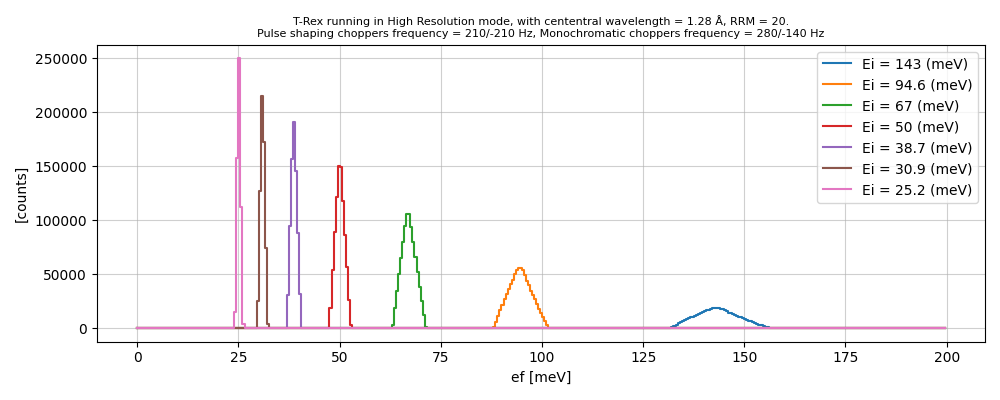

In [23]:
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        ef=sc.arange("ef", 0, 200, 0.5, unit="meV")
    )
    for reduced in reduced_elastic_2
}

fig, ax = plt.subplots(figsize=(10, 4))
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex), fontsize=8)
ax.grid(alpha=0.6)
# ax.set_ylim([-50, 12_000])
fig.tight_layout()

In [24]:
cen = [
    (da.data * sc.midpoints(da.coords["ef"])).sum() / da.sum()
    for da in hist_dict.values()
]
fwhm = [
    2.355
    * sc.sqrt(
        (da.data * (sc.midpoints(da.coords["ef"] - cen[i].data)) ** 2).sum() / da.sum()
    )
    for i, da in enumerate(hist_dict.values())
]
print(f"Ei  = {[round(float(v.data.value), 4) for v in cen]} meV")
print(f"delta en FWHM  = {[round(float(v.data.value), 4) for v in fwhm]} meV")
ratio = [round(float(f.data / c.data), 3) for f, c in zip(fwhm, cen)]
print(f"delta en over ei = {ratio}")

Ei  = [143.3488, 94.6126, 67.0802, 50.0273, 38.7368, 30.8757, 25.1882] meV
delta en FWHM  = [11.9898, 6.4694, 3.8959, 2.5364, 1.7329, 1.2501, 0.9315] meV
delta en over ei = [0.084, 0.068, 0.058, 0.051, 0.045, 0.04, 0.037]


# Having M2 slowed down by a factor of 4

In [25]:
trex = Instrument(
    central_wavelength, rrm, mode, T_OFFSET, chopper_slowdown=(1, 1, 1, 4)
)
trex.source = Source(
    facility="ess-trex", neutrons=5_000_000, optimize_for=trex.choppers
)
res_elastic_rrm20_3 = trex.run()
# sample = Sample(en={"uniform": (40, 60)})
res_inelastic_rrm20_3 = trex.run(sample)

/var/folders/s5/6527bxpx7xnbbzxz94s_d2xm0000gp/T/ipykernel_53495/2704027506.py:10: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


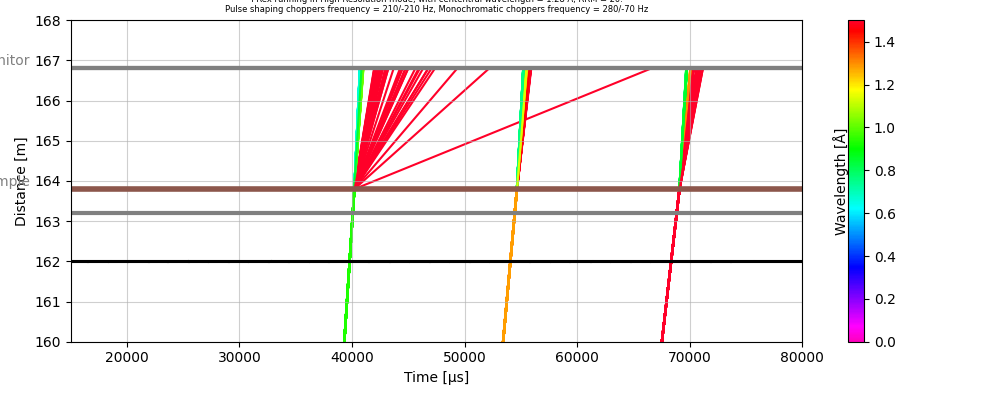

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

res_inelastic_rrm20_3.plot(ax=ax, vmin=0, vmax=1.5)
ax.set_xlim([15_000, 80_000])
ax.set_ylim([160, 168])
ax.set_title(str(trex), fontsize=6)
ax.grid(alpha=0.6)
fig.tight_layout()

In [27]:
data = res_inelastic_rrm20_3.detectors["Detector"].data["pulse", 0]
data = data[~data.masks["blocked_by_others"]]
pp.plot(data.hist(toa=sc.arange("toa", 15_000, 80_000, 1, unit="us")), grid=True)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [28]:
ei_ef_ratio = 0.0
trex.wrap_frame(res_elastic_rrm20_1)
params_3 = trex.unwrap_frame(res_elastic_rrm20_3, ei_ef_ratio=ei_ef_ratio)
# trex.wrap_frame(res_inelastic_rrm22)
reduced_ins_3 = trex.toa_to_energy(res_inelastic_rrm20_3, *params_3)
for reduced in reduced_ins_3:
    reduced.data *= reduced.coords["kf_over_ki"]
    reduced.data *= sc.sqrt(reduced.coords["ei"] / reduced.coords["ef"])

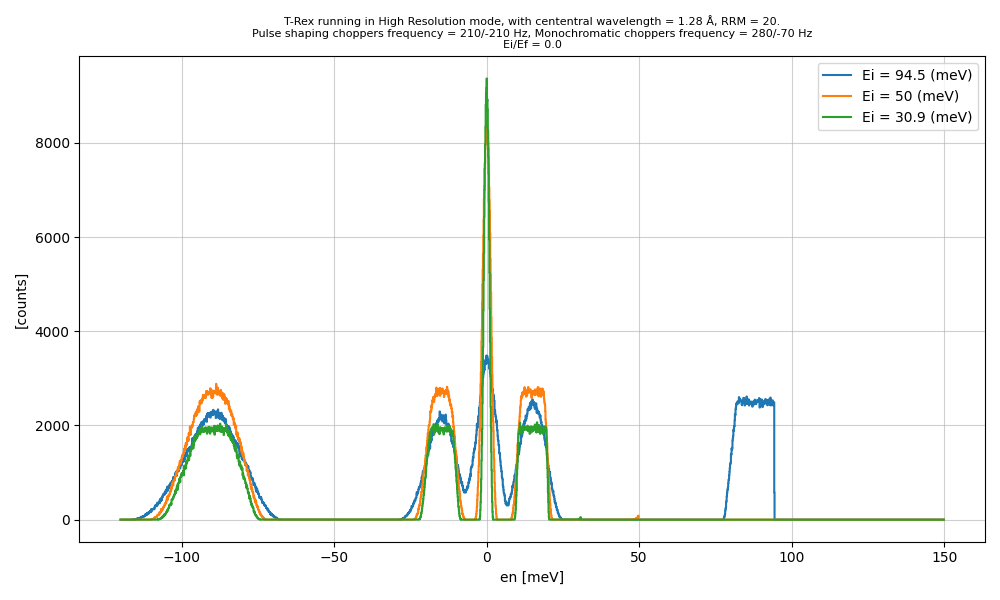

In [29]:
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", -120, 150, 0.1, unit="meV")
    )
    for reduced in reduced_ins_3
}

fig, ax = plt.subplots(figsize=(10, 6))
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex) + f"\nEi/Ef = {ei_ef_ratio}", fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

In [30]:
trex.wrap_frame(res_elastic_rrm20_3)
params_3 = trex.unwrap_frame(res_elastic_rrm20_3, ei_ef_ratio=0.0)
reduced_elastic_3 = trex.toa_to_energy(res_elastic_rrm20_3, *params_3)

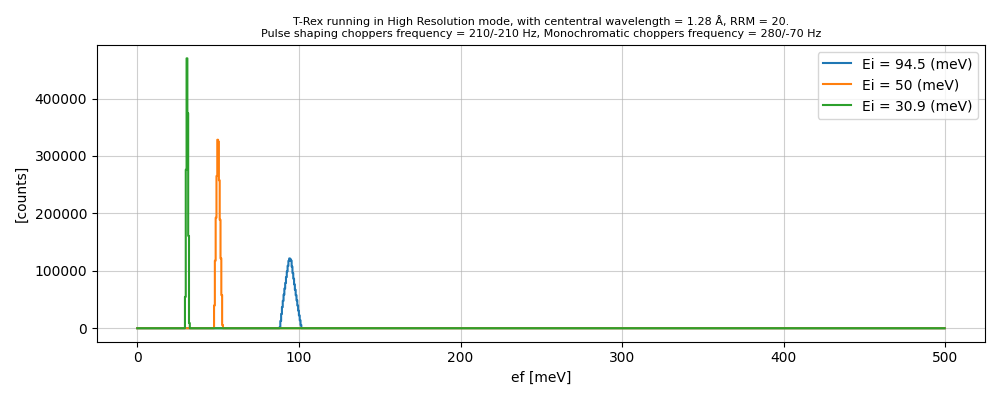

In [31]:
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        ef=sc.arange("ef", 0, 500, 0.5, unit="meV")
    )
    for reduced in reduced_elastic_3
}

fig, ax = plt.subplots(figsize=(10, 4))
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex), fontsize=8)
ax.grid(alpha=0.6)
# ax.set_ylim([-50, 12_000])
fig.tight_layout()

In [32]:
cen = [
    (da.data * sc.midpoints(da.coords["ef"])).sum() / da.sum()
    for da in hist_dict.values()
]
fwhm = [
    2.355
    * sc.sqrt(
        (da.data * (sc.midpoints(da.coords["ef"] - cen[i].data)) ** 2).sum() / da.sum()
    )
    for i, da in enumerate(hist_dict.values())
]
print(f"Ei  = {[round(float(v.data.value), 4) for v in cen]} meV")
print(f"delta en FWHM  = {[round(float(v.data.value), 4) for v in fwhm]} meV")
ratio = [round(float(f.data / c.data), 3) for f, c in zip(fwhm, cen)]
print(f"delta en over ei = {ratio}")

Ei  = [94.6078, 50.0276, 30.8756] meV
delta en FWHM  = [6.4638, 2.5332, 1.247] meV
delta en over ei = [0.068, 0.051, 0.04]
